### T-distributed Stochastic Neighbor Embedding (t-SNE):
- t-(SNE) is a non linear dimensionality reduction technique used for visualizing high-dimensional data in a lower-dimensional space mainly in 2D or 3D.
- Unlike linear methods such as Principal Component Analysis(PCA), t-SNE focus on perserving the local structure and patterns of the data.
- t-SNE works by looking at the similarity between data points in the high-dimensional space.
- The similarity is computed as conditional probability.
- It calculates how likely it is that one data point would be near another.
### Implementation of t-SNE on MNIST Dataset:
#### 1. Importing Libraries:


In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_openml

#### 2. Load Datasets:
- Now let's load the MNIST dataset into pandas dataframe.

In [17]:
mnist = fetch_openml('mnist_784', version=1)

d = mnist.data
l = mnist.target

df = pd.DataFrame(d)
df['label'] = l

print(df.head(4))

   pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  pixel9  \
0       0       0       0       0       0       0       0       0       0   
1       0       0       0       0       0       0       0       0       0   
2       0       0       0       0       0       0       0       0       0   
3       0       0       0       0       0       0       0       0       0   

   pixel10  ...  pixel776  pixel777  pixel778  pixel779  pixel780  pixel781  \
0        0  ...         0         0         0         0         0         0   
1        0  ...         0         0         0         0         0         0   
2        0  ...         0         0         0         0         0         0   
3        0  ...         0         0         0         0         0         0   

   pixel782  pixel783  pixel784  label  
0         0         0         0      5  
1         0         0         0      0  
2         0         0         0      4  
3         0         0         0      1  

[4 rows x 78

#### 3. Standardize the Data:
- Before applying the t-SNE algorithm on the dataset we must standardize the data.
- As we know that the t-SNE algorithm is a complex algorithm which utilizes some complex non-linear methods.

In [18]:
from sklearn.preprocessing import StandardScaler

standard_scaler = StandardScaler()
standard_scaler = standard_scaler.fit_transform(df)
print(standard_scaler.shape)

(70000, 785)


#### 4. Applying the t-SNE:
- t-SNE is used to visualize high-dimensional data in a lower dimensional space.
- n_components=2 - spcifies that the data should be reduced to 2 dimesions, which is ideal for creating visualizations.
- random_state=0 - Sets the random seed to 0, ensuring that the results are reproducible across runs.

In [19]:
data_1000 = standard_scaler[0:1000, :]
labels_1000 = l[0:1000]

model = TSNE(n_components=2, random_state=0)

tsne_data = model.fit_transform(data_1000)

#### 5. Visualize the data:
- Now let's reduce the 784 columns data to 2 dimensions so that we can create a scatter plot to visualize the same.

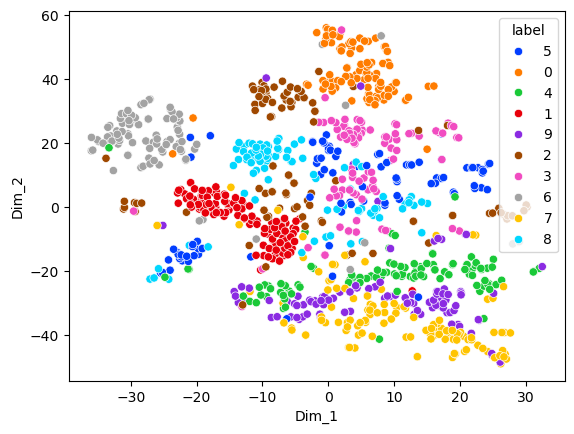

In [20]:
tsne_data = np.vstack((tsne_data.T, labels_1000)).T
tsne_df = pd.DataFrame(data = tsne_data,
     columns =("Dim_1", "Dim_2", "label"))

sns.scatterplot(data=tsne_df, x='Dim_1', y='Dim_2',
               hue='label', palette="bright")
plt.show()

### Advantages of t-SNE:
- Great for Visualization
- Preserve Local Structure
- Non-Linear Capability
- Cluster Seperation
### Disadvantages of t-SNE:
- Computationally Intensive
- Non-deterministic Output
- Not Scalable for Large Datasets
- Not Good for Downstream Tasks
- No Global Structure Preservation